# Advanced Machine Learning — Lab3
## Deep Reinforcement Learning: DQN & Policy Gradients

**Full name :** Djouaher Yasmine

**Group :** SID1

> **Module:** Machine Learning under Real-World Constraints  
> **Phase:** Phase 1 — Temporal Adaptation  
> **Duration:** 2 hours  
> **Prerequisites:** Week 2 (Q-Learning, MDPs)

---

## Learning Objectives

By the end of this lab you will be able to:
1. Explain why tabular Q-Learning fails on large state spaces
2. Implement a **Deep Q-Network (DQN)** with Experience Replay and Target Network
3. Implement **REINFORCE** (Monte-Carlo Policy Gradient)
4. Train both agents on **CartPole-v1**
5. Compare DQN and REINFORCE in terms of stability and sample efficiency
6. Understand the role of each DQN trick through ablation

---

##  Theoretical Recap

### From Tabular Q-Learning to DQN

In Week 2, we stored Q-values in a table of size $|\mathcal{S}| \times |\mathcal{A}|$.  
This breaks down when states are continuous or high-dimensional (e.g. pixels).

**Solution:** Approximate $Q(s,a)$ with a neural network:
$$Q(s,a;\theta) \approx Q^*(s,a)$$

The network takes state $s$ as input and outputs Q-values for all actions.

### DQN Loss Function

We minimise the Mean Squared TD Error:
$$\mathcal{L}(\theta) = \mathbb{E}\left[\left(\underbrace{r + \gamma \max_{a'} Q(s',a';\theta^-)}_{\text{TD target}} - Q(s,a;\theta)\right)^2\right]$$

where $\theta^-$ are the **frozen target network** parameters.

### Two Key Tricks in DQN

| Trick | Problem it solves | How |
|-------|------------------|-----|
| **Experience Replay** | Correlated consecutive samples break SGD | Store transitions, sample mini-batches randomly |
| **Target Network** | Moving targets cause divergence | Use frozen copy $\theta^-$, update every $C$ steps |

### Policy Gradient — REINFORCE

Instead of learning a value function, directly optimise the policy $\pi_\theta$:
$$\nabla_\theta J(\theta) = \mathbb{E}_\pi\left[\sum_t \nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

where $G_t = \sum_{k=t}^{T} \gamma^{k-t} r_k$ is the return from step $t$.

**Intuition:** Increase probability of actions that led to high return.

---

## Part 0 — Setup & Imports

In [1]:
# Uncomment on Google Colab if needed
# !pip install -q gymnasium tensorflow numpy matplotlib

import numpy as np
import random
import collections
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import gymnasium as gym



import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

print('TensorFlow:', tf.__version__)
print('Gymnasium: ', gym.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))


TensorFlow: 2.19.0
Gymnasium:  1.2.3
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


---
## Part 1 — CartPole Environment

**CartPole-v1** is the classic RL benchmark:
- A pole is attached to a cart on a frictionless track
- Goal: keep the pole upright by pushing left or right

**State** (4 continuous values):
| Index | Variable | Range |
|-------|----------|-------|
| 0 | Cart position | \[-4.8, 4.8\] |
| 1 | Cart velocity | \(-\infty, +\infty\) |
| 2 | Pole angle | \[-0.418, 0.418\] rad |
| 3 | Pole angular velocity | \(-\infty, +\infty\) |

**Action space:** {0 = push left, 1 = push right}  
**Reward:** +1 for every step the pole stays up  
**Done:** pole angle > 12° or cart out of bounds  
**Success:** average reward ≥ 475 over 100 episodes  

### Why can't we use tabular Q-Learning here?
The state is a vector of 4 **continuous** values → infinite state space → table is impossible.

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Shape: (4,)
  Low:  [-4.8               -inf -0.41887903        -inf]
  High: [4.8               inf 0.41887903        inf]

Action space: Discrete(2)
  n = 2 (0=left, 1=right)

Random policy: survived 19 steps, total reward = 19.0


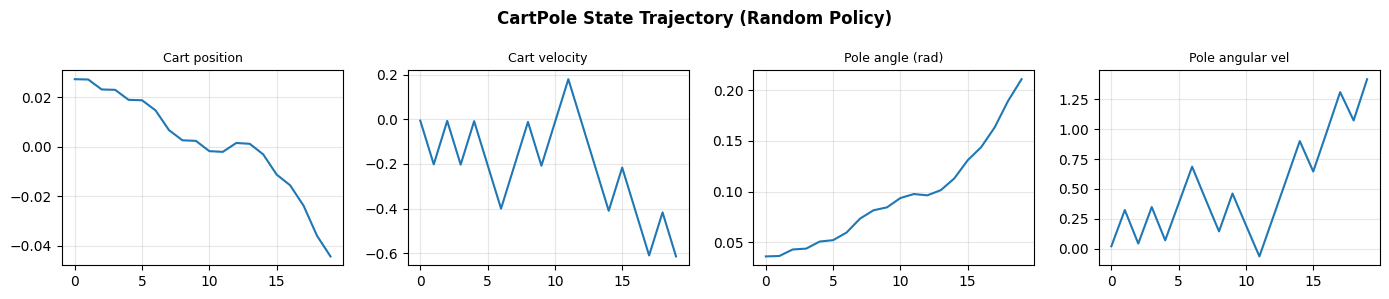

In [2]:
# Create and explore CartPole environment
env = gym.make('CartPole-v1')

print('Observation space:', env.observation_space)
print('  Shape:', env.observation_space.shape)
print('  Low: ', env.observation_space.low)
print('  High:', env.observation_space.high)
print()
print('Action space:', env.action_space)
print('  n =', env.action_space.n, '(0=left, 1=right)')

# Run one random episode to observe dynamics
obs, _ = env.reset(seed=SEED)
total_reward = 0
trajectory = [obs.copy()]

for step in range(200):
    action = env.action_space.sample()   # random policy
    obs, reward, terminated, truncated, _ = env.step(action)
    total_reward += reward
    trajectory.append(obs.copy())
    if terminated or truncated:
        break

print(f'\nRandom policy: survived {step+1} steps, total reward = {total_reward}')

# Visualise pole angle over time
traj = np.array(trajectory)
fig, axes = plt.subplots(1, 4, figsize=(14, 3))
labels = ['Cart position', 'Cart velocity', 'Pole angle (rad)', 'Pole angular vel']
for i, (ax, lbl) in enumerate(zip(axes, labels)):
    ax.plot(traj[:, i])
    ax.set_title(lbl, fontsize=9)
    ax.grid(True, alpha=0.3)
plt.suptitle('CartPole State Trajectory (Random Policy)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Exercise 1 — Understanding the State Space

**Q1.** Why is tabular Q-Learning impossible for CartPole?  
**Q2.** Suppose we discretise each state dimension into 10 bins. How many total states would the table have?  
**Q3.** What would the DQN input and output dimensions be for CartPole?  
**Q4.** A random policy survives ~10-20 steps. What score would a good policy achieve? Why 475 and not 500?

#### Answers :

**A1.** Because the state space is **continuous** (4 real-valued variables). Tabular Q-Learning requires a **finite set of discrete states**, so the Q-table would be infinitely large.

**A2.** CartPole has **4 state dimensions**.
So the Q-table would contain **10,000 states**.

**A3.**   
- **Input dimension:** 4 (state vector)  
- **Output dimension:** 2 (Q-value for each action: left or right)


**A4.** A good policy achieves **close to 500 reward** (maximum episode length).

The success threshold is **475 over 100 episodes** because:
- RL training is **stochastic**
- Even strong policies may occasionally fail
- 475 indicates **near-optimal performance**

In [3]:
# --- Exercise 1 — YOUR ANSWERS HERE ---

# Q2: Number of states after discretisation
bins_per_dim = 10
n_dims = 4
n_states_discretised = bins_per_dim ** n_dims
print(f'Q2: Discretised state space size = {n_states_discretised:,}')

# Q3: DQN dimensions
input_dim  = 4 # state dimension
output_dim = 2 # number of actions
print(f'Q3: DQN input = {input_dim}, output = {output_dim}')

Q2: Discretised state space size = 10,000
Q3: DQN input = 4, output = 2


---
## Part 2 — Experience Replay Buffer

**Problem with online learning:**  
Consecutive transitions $(s_t, a_t, r_t, s_{t+1})$ are highly correlated → SGD assumption violated.

**Solution:** Store transitions in a circular buffer of capacity $N$.  
At each update, sample a random mini-batch of size $B$.

```
Buffer (capacity N):   [t₁, t₂, t₃, ..., tₙ]
                              ↕ random sample ↕
Mini-batch (size B):   [t₅, t₁₂, t₃, t₉₉, ...]   → gradient update
```

This **decorrelates** samples and reuses past experience.

In [ ]:
class ReplayBuffer:
    """
    Circular experience replay buffer.

    Stores transitions (s, a, r, s', done) and allows
    random mini-batch sampling for DQN training.
    """

    def __init__(self, capacity=10_000):
        """
        Args:
            capacity: Maximum number of transitions to store.
                      Oldest entries are overwritten when full.
        """
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Store one transition."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """
        Sample a random mini-batch.

        Returns:
            Tuple of numpy arrays: (states, actions, rewards, next_states, dones)
        """
        batch = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)
        return (
            np.array(states,      dtype=np.float32),
            np.array(actions,     dtype=np.int32),
            np.array(rewards,     dtype=np.float32),
            np.array(next_states, dtype=np.float32),
            np.array(dones,       dtype=np.float32),
        )

    def __len__(self):
        return len(self.buffer)

# Quick test
buf = ReplayBuffer(capacity=100)
for _ in range(50):
    s  = np.random.randn(4)
    a  = np.random.randint(2)
    r  = np.random.randn()
    s2 = np.random.randn(4)
    d  = False
    buf.push(s, a, r, s2, d)

states, actions, rewards, next_states, dones = buf.sample(8)
print('Buffer size:', len(buf))
print('Sampled batch shapes:')
print('  states:     ', states.shape)
print('  actions:    ', actions.shape)
print('  rewards:    ', rewards.shape)
print('  next_states:', next_states.shape)
print('✅ ReplayBuffer working correctly')

Buffer size: 50
Sampled batch shapes:
  states:      (8, 4)
  actions:     (8,)
  rewards:     (8,)
  next_states: (8, 4)
✅ ReplayBuffer working correctly


---
## Part 3 — DQN Network Architecture

We build a simple MLP that maps states to Q-values:

```
Input  [4]  →  Dense(64, ReLU)  →  Dense(64, ReLU)  →  Output [2]
```

We maintain **two identical networks**:
- `online_network`: trained at every step
- `target_network`: frozen copy, updated every `C` steps

**Why a target network?**  
Without it, the TD target $r + \gamma\max_{a'}Q(s',a';\theta)$ changes at every gradient step → the network chases a moving target → training diverges.

In [5]:
def build_dqn(state_dim, n_actions, hidden_units=64):
    """
    Build a simple DQN (MLP).

    Args:
        state_dim  : int — dimension of state vector
        n_actions  : int — number of discrete actions
        hidden_units: int — neurons per hidden layer

    Returns:
        model: Keras Model  input=(batch, state_dim), output=(batch, n_actions)
    """
    model = keras.Sequential([
        layers.Input(shape=(state_dim,)),
        layers.Dense(hidden_units, activation='relu',
                     kernel_initializer='he_normal'),
        layers.Dense(hidden_units, activation='relu',
                     kernel_initializer='he_normal'),
        layers.Dense(n_actions,    activation='linear'),   # No activation on output!
    ], name='DQN')
    return model

# Instantiate and inspect
STATE_DIM = env.observation_space.shape[0]   # 4
N_ACTIONS  = env.action_space.n              # 2

online_net = build_dqn(STATE_DIM, N_ACTIONS)
target_net = build_dqn(STATE_DIM, N_ACTIONS)

# Synchronise weights
target_net.set_weights(online_net.get_weights())

online_net.summary()

# Test forward pass
dummy_state = np.random.randn(1, STATE_DIM).astype(np.float32)
q_vals = online_net(dummy_state)
print('Q-values for dummy state:', q_vals.numpy())
print('Greedy action:', np.argmax(q_vals.numpy()))

Model: "DQN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,610 (18.01 KB)

 Trainable params: 4,610 (18.01 KB)

 Non-trainable params: 0 (0.00 B)

Q-values for dummy state: [[-0.10620992 -0.0244559 ]]
Greedy action: 1


### Exercise 2 — Why Linear Output Activation?

**Q1.** Why do we use `activation='linear'` (i.e. no activation) on the output layer?  
**Q2.** Why do we use `activation='relu'` on hidden layers and not `sigmoid`?  
**Q3.** The target network and online network start with the same weights. How often should we synchronise them? What happens if we sync too frequently? Too rarely?  
**Q4.** In the DQN loss, why do we not propagate gradients through the target network?

###Answers :

**A1.** Q-values are real numbers that can take any value (positive or negative). Using a linear activation keeps the output unbounded so the network can represent any Q-value.

**A2.** ReLU avoids the vanishing gradient problem that occurs with sigmoid and allows faster training. Sigmoid also saturates for large inputs, which slows learning in deep networks.

**A3.** Typically every few hundred or thousand training steps (100 – 1 000 steps).  
- If synchronised too frequently: the target changes too quickly and training becomes unstable.  
- If synchronised too rarely: targets become outdated and learning becomes slow.

**A4.** The target network provides a stable target for the TD update. If gradients flowed through it, the target would change during the update, defeating the purpose of having a fixed target and making training unstable.

---
## Part 4 — DQN Agent

We now implement the full DQN agent.  
The training loop follows the original Mnih et al. (2015) algorithm:

```
For each step:
  1. ε-greedy action selection using online_net
  2. Store (s, a, r, s', done) in replay buffer
  3. If buffer ≥ batch_size:
       a. Sample mini-batch
       b. Compute TD targets using target_net
       c. Gradient step on online_net
  4. Every C steps: target_net ← online_net
  5. Decay ε
```

In [6]:
class DQNAgent:
    """
    Deep Q-Network agent (Mnih et al., 2015).

    Key components:
      - Online network  : learns at every step
      - Target network  : frozen copy, stabilises training
      - Replay buffer   : breaks temporal correlations
      - ε-greedy policy : balances exploration vs exploitation
    """

    def __init__(
        self,
        state_dim,
        n_actions,
        lr=1e-3,
        gamma=0.99,
        epsilon=1.0,
        epsilon_min=0.01,
        epsilon_decay=0.995,
        buffer_capacity=10_000,
        batch_size=64,
        target_update_freq=100,
    ):
        self.state_dim   = state_dim
        self.n_actions   = n_actions
        self.gamma       = gamma
        self.epsilon     = epsilon
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        self.batch_size  = batch_size
        self.target_update_freq = target_update_freq
        self.step_count  = 0

        # Networks
        self.online_net = build_dqn(state_dim, n_actions)
        self.target_net = build_dqn(state_dim, n_actions)
        self.target_net.set_weights(self.online_net.get_weights())

        # Optimiser
        self.optimiser = keras.optimizers.Adam(learning_rate=lr)

        # Replay buffer
        self.replay_buffer = ReplayBuffer(capacity=buffer_capacity)

        # Logging
        self.losses = []

    # ----------------------------------------------------------
    def select_action(self, state, mode='train'):
        """
        ε-greedy action selection.

        Args:
            state : numpy array (state_dim,)
            mode  : 'train' (with ε) or 'eval' (greedy)
        Returns:
            action: int
        """
        if mode == 'train' and np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        state_t = tf.convert_to_tensor(state[np.newaxis], dtype=tf.float32)
        q_vals  = self.online_net(state_t, training=False)
        return int(tf.argmax(q_vals[0]).numpy())

    # ----------------------------------------------------------
    @tf.function
    def _train_step(self, states, actions, rewards, next_states, dones):
        """
        One gradient update step.

        Loss = MSE(TD_target - Q(s,a;θ))
        where TD_target = r + γ·max_{a'} Q(s',a'; θ⁻)
        """
        # --- TD targets (no gradient through target_net) ---
        next_q    = self.target_net(next_states, training=False)   # (B, A)
        max_next_q = tf.reduce_max(next_q, axis=1)                  # (B,)
        td_targets = rewards + self.gamma * max_next_q * (1.0 - dones)  # (B,)

        # --- Online network gradient ---
        with tf.GradientTape() as tape:
            q_all  = self.online_net(states, training=True)         # (B, A)
            # Pick Q-value for the action actually taken
            action_idx = tf.stack(
                [tf.range(tf.shape(actions)[0]), actions], axis=1
            )
            q_taken = tf.gather_nd(q_all, action_idx)               # (B,)
            loss = tf.reduce_mean(tf.square(td_targets - q_taken))

        grads = tape.gradient(loss, self.online_net.trainable_variables)
        self.optimiser.apply_gradients(
            zip(grads, self.online_net.trainable_variables)
        )
        return loss

    # ----------------------------------------------------------
    def train_step(self, state, action, reward, next_state, done):
        """Store transition and maybe update networks."""
        self.replay_buffer.push(state, action, reward, next_state, done)
        self.step_count += 1

        if len(self.replay_buffer) < self.batch_size:
            return  # Not enough samples yet

        # Sample and train
        states, actions, rewards, next_states, dones = \
            self.replay_buffer.sample(self.batch_size)

        loss = self._train_step(
            tf.constant(states),
            tf.constant(actions),
            tf.constant(rewards),
            tf.constant(next_states),
            tf.constant(dones),
        )
        self.losses.append(float(loss))

        # Sync target network
        if self.step_count % self.target_update_freq == 0:
            self.target_net.set_weights(self.online_net.get_weights())

        # Decay exploration
        self.epsilon = max(self.epsilon_min,
                           self.epsilon * self.epsilon_decay)

print('✅ DQNAgent class defined')

✅ DQNAgent class defined


---
## Part 5 — Training the DQN

We now run the training loop.  
**Expected results:** CartPole solved (score ≥ 475) within ~300–500 episodes.

In [7]:
def run_dqn_training(n_episodes=500, print_every=50):
    """Full DQN training loop on CartPole-v1."""

    train_env = gym.make('CartPole-v1')
    agent = DQNAgent(
        state_dim   = train_env.observation_space.shape[0],
        n_actions   = train_env.action_space.n,
        lr          = 1e-3,
        gamma       = 0.99,
        epsilon     = 1.0,
        epsilon_min = 0.01,
        epsilon_decay = 0.995,
        buffer_capacity = 10_000,
        batch_size  = 64,
        target_update_freq = 100,
    )

    episode_rewards = []

    for ep in range(n_episodes):
        state, _ = train_env.reset()
        ep_reward = 0

        while True:
            action = agent.select_action(state, mode='train')
            next_state, reward, terminated, truncated, _ = train_env.step(action)
            done = terminated or truncated

            agent.train_step(state, action, reward, next_state, float(done))

            state      = next_state
            ep_reward += reward

            if done:
                break

        episode_rewards.append(ep_reward)

        if (ep + 1) % print_every == 0:
            avg = np.mean(episode_rewards[-100:])
            print(f'Ep {ep+1:4d} | Avg(100)={avg:6.1f} | ε={agent.epsilon:.3f} '
                  f'| Buffer={len(agent.replay_buffer):5d}')

    train_env.close()
    return agent, episode_rewards


print('Training DQN on CartPole-v1 ...')
print('=' * 60)
dqn_agent, dqn_rewards = run_dqn_training(n_episodes=500)

Training DQN on CartPole-v1 ...
Ep   50 | Avg(100)=  12.5 | ε=0.060 | Buffer=  625
Ep  100 | Avg(100)=  87.0 | ε=0.010 | Buffer= 8701
Ep  150 | Avg(100)= 163.1 | ε=0.010 | Buffer=10000
Ep  200 | Avg(100)= 207.2 | ε=0.010 | Buffer=10000
Ep  250 | Avg(100)= 335.9 | ε=0.010 | Buffer=10000
Ep  300 | Avg(100)= 334.6 | ε=0.010 | Buffer=10000
Ep  350 | Avg(100)= 197.9 | ε=0.010 | Buffer=10000
Ep  400 | Avg(100)= 253.0 | ε=0.010 | Buffer=10000
Ep  450 | Avg(100)= 354.6 | ε=0.010 | Buffer=10000
Ep  500 | Avg(100)= 252.5 | ε=0.010 | Buffer=10000


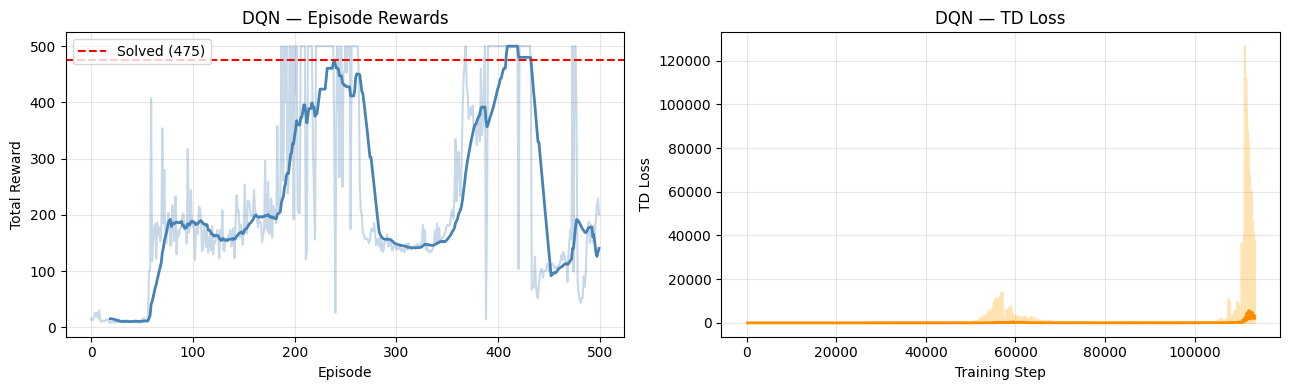

In [8]:
# --- Plot DQN learning curve ---
def smooth(x, w=20):
    return np.convolve(x, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(dqn_rewards, alpha=0.3, color='steelblue')
ax.plot(range(19, len(dqn_rewards)), smooth(dqn_rewards, 20),
        color='steelblue', linewidth=2)
ax.axhline(475, color='red', linestyle='--', label='Solved (475)')
ax.set_xlabel('Episode'); ax.set_ylabel('Total Reward')
ax.set_title('DQN — Episode Rewards'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
if dqn_agent.losses:
    ax.plot(dqn_agent.losses, alpha=0.3, color='orange')
    if len(dqn_agent.losses) > 200:
        ax.plot(range(199, len(dqn_agent.losses)),
                smooth(dqn_agent.losses, 200),
                color='darkorange', linewidth=2)
ax.set_xlabel('Training Step'); ax.set_ylabel('TD Loss')
ax.set_title('DQN — TD Loss'); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_training.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise 3 — Ablation Study

The two key DQN tricks are **Experience Replay** and **Target Network**.  
Let's measure their individual impact.

**Task:** Complete the function `run_ablation` that trains a DQN variant by disabling one trick at a time.

| Variant | Replay Buffer | Target Network |
|---------|--------------|----------------|
| Full DQN | ✅ | ✅ |
| No target net | ✅ | ❌ (online = target) |
| No replay | ❌ (batch=1) | ✅ |

Running ablation study (3 variants × 300 episodes) ...
This may take a few minutes.
Variant A done
Variant B done


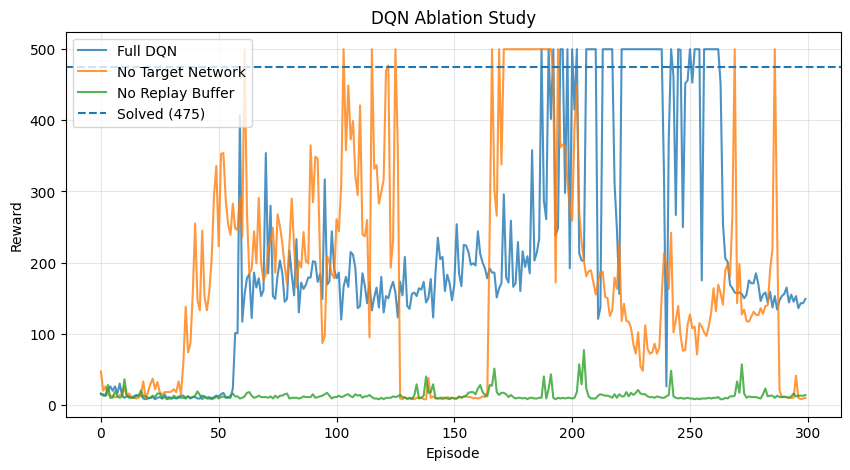

In [9]:
def run_ablation(use_replay=True, use_target_net=True, n_episodes=300):
    """
    Train DQN with specific components enabled/disabled.

    Args:
        use_replay      : if False, use batch_size=1 (no replay)
        use_target_net  : if False, sync target every step (same as online)
        n_episodes      : training episodes

    Returns:
        rewards list
    """
    abl_env = gym.make('CartPole-v1')

    agent = DQNAgent(
        state_dim   = abl_env.observation_space.shape[0],
        n_actions   = abl_env.action_space.n,
        batch_size  = 64 if use_replay else 1,
        target_update_freq = 100 if use_target_net else 1,  # sync every step if disabled
    )

    rewards = []

    for ep in range(n_episodes):
        state, _ = abl_env.reset()
        ep_r = 0
        while True:
            action = agent.select_action(state, mode='train')
            ns, r, term, trunc, _ = abl_env.step(action)
            done = term or trunc
            agent.train_step(state, action, r, ns, float(done))
            state = ns; ep_r += r
            if done: break
        rewards.append(ep_r)

    abl_env.close()
    return rewards


print('Running ablation study (3 variants × 300 episodes) ...')
print('This may take a few minutes.')

# --- TODO: run and store results for each variant ---

# Full DQN (already have dqn_rewards)

# Variant A: no target network
rewards_no_target = run_ablation(use_replay=True,  use_target_net=False, n_episodes=300)
print('Variant A done')

# Variant B: no experience replay
rewards_no_replay = run_ablation(use_replay=False, use_target_net=True,  n_episodes=300)
print('Variant B done')

# --- TODO: plot and compare the three curves ---
# YOUR CODE HERE

# --- Plot comparison of ablation variants ---

plt.figure(figsize=(10,5))

plt.plot(dqn_rewards[:300], label='Full DQN', alpha=0.8)
plt.plot(rewards_no_target, label='No Target Network', alpha=0.8)
plt.plot(rewards_no_replay, label='No Replay Buffer', alpha=0.8)

plt.axhline(475, linestyle='--', label='Solved (475)')

plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DQN Ablation Study')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()


---
## Part 6 — REINFORCE (Policy Gradient)

**Key idea:** Instead of learning Q-values, directly parameterise the policy:
$$\pi_\theta(a|s) = \text{softmax}(\text{network}(s))$$

**Policy Gradient Theorem:**
$$\nabla_\theta J(\theta) = \mathbb{E}_\pi\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot G_t\right]$$

**REINFORCE algorithm:**
1. Run full episode, collect $(s_0,a_0,r_0,\ldots,s_T)$
2. Compute returns $G_t = \sum_{k=t}^T \gamma^{k-t} r_k$
3. Update: $\theta \leftarrow \theta + \alpha \sum_t \nabla_\theta \log\pi_\theta(a_t|s_t)\cdot G_t$

**Note:** REINFORCE is **on-policy** and uses Monte-Carlo returns (not TD).

### Variance Reduction — Baseline

Raw returns $G_t$ have high variance → slow learning.  
We subtract a **baseline** $b$ (often mean return):
$$\nabla_\theta J = \mathbb{E}\left[\nabla_\theta \log \pi_\theta(a_t|s_t) \cdot (G_t - b)\right]$$

This does **not** introduce bias (the baseline is independent of action).

In [10]:
def build_policy_net(state_dim, n_actions, hidden=64):
    """
    Policy network: maps state -> action probabilities.
    Output uses softmax so probabilities sum to 1.
    """
    model = keras.Sequential([
        layers.Input(shape=(state_dim,)),
        layers.Dense(hidden, activation='relu'),
        layers.Dense(hidden, activation='relu'),
        layers.Dense(n_actions, activation='softmax'),  # probabilities!
    ], name='PolicyNet')
    return model


class REINFORCEAgent:
    """
    Monte-Carlo Policy Gradient (Williams, 1992).
    Collects full episodes, then performs one gradient update.
    """

    def __init__(self, state_dim, n_actions, lr=1e-3, gamma=0.99, use_baseline=True):
        self.gamma        = gamma
        self.use_baseline = use_baseline
        self.policy       = build_policy_net(state_dim, n_actions)
        self.optimiser    = keras.optimizers.Adam(lr)
        self.episode_rewards = []

    def select_action(self, state):
        """
        Sample action from current policy distribution.
        Returns action (int) and its log probability.
        """
        state_t = tf.convert_to_tensor(state[np.newaxis], dtype=tf.float32)
        probs   = self.policy(state_t, training=False)[0]  # (n_actions,)
        action  = np.random.choice(len(probs), p=probs.numpy())
        return action

    def compute_returns(self, rewards):
        """
        Compute discounted returns from a list of step rewards.

        G_t = r_t + γ·r_{t+1} + γ²·r_{t+2} + ...

        Args:
            rewards: list of floats (length T)
        Returns:
            returns: numpy array (length T)
        """
        returns = np.zeros(len(rewards))
        G = 0.0
        for t in reversed(range(len(rewards))):
            G = rewards[t] + self.gamma * G
            returns[t] = G
        return returns

    def update(self, states, actions, rewards):
        """
        Policy gradient update after one complete episode.

        Loss = -Σ_t log π(a_t|s_t) · (G_t - baseline)
        """
        returns = self.compute_returns(rewards)

        if self.use_baseline:
            returns = returns - np.mean(returns)  # subtract mean baseline

        returns = tf.constant(returns, dtype=tf.float32)
        states  = tf.constant(np.array(states), dtype=tf.float32)
        actions = tf.constant(actions, dtype=tf.int32)

        with tf.GradientTape() as tape:
            probs     = self.policy(states, training=True)          # (T, A)
            log_probs = tf.math.log(probs + 1e-8)                   # (T, A)
            # Select log_prob of the action taken
            idx       = tf.stack([tf.range(tf.shape(actions)[0]), actions], axis=1)
            chosen_lp = tf.gather_nd(log_probs, idx)                # (T,)
            # Policy gradient loss (negative because we gradient-ASCENT on J)
            loss      = -tf.reduce_mean(chosen_lp * returns)

        grads = tape.gradient(loss, self.policy.trainable_variables)
        self.optimiser.apply_gradients(
            zip(grads, self.policy.trainable_variables)
        )
        return float(loss)

print('✅ REINFORCEAgent class defined')

✅ REINFORCEAgent class defined


In [11]:
def run_reinforce_training(n_episodes=600, print_every=100):
    """Full REINFORCE training loop on CartPole-v1."""

    pg_env   = gym.make('CartPole-v1')
    pg_agent = REINFORCEAgent(
        state_dim  = pg_env.observation_space.shape[0],
        n_actions  = pg_env.action_space.n,
        lr=2e-3, gamma=0.99, use_baseline=True,
    )
    rewards_hist = []
    loss_hist    = []

    for ep in range(n_episodes):
        state, _ = pg_env.reset()
        ep_states, ep_actions, ep_rewards = [], [], []

        # --- Collect one episode ---
        while True:
            action = pg_agent.select_action(state)
            ns, r, term, trunc, _ = pg_env.step(action)
            ep_states.append(state)
            ep_actions.append(action)
            ep_rewards.append(r)
            state = ns
            if term or trunc:
                break

        # --- One gradient update ---
        loss = pg_agent.update(ep_states, ep_actions, ep_rewards)

        rewards_hist.append(sum(ep_rewards))
        loss_hist.append(loss)

        if (ep + 1) % print_every == 0:
            avg = np.mean(rewards_hist[-100:])
            print(f'Ep {ep+1:4d} | Avg(100)={avg:6.1f} | Loss={loss:.4f}')

    pg_env.close()
    return pg_agent, rewards_hist, loss_hist


print('Training REINFORCE on CartPole-v1 ...')
pg_agent, pg_rewards, pg_losses = run_reinforce_training(n_episodes=600)

Training REINFORCE on CartPole-v1 ...
Ep  100 | Avg(100)=  60.8 | Loss=-1.0258
Ep  200 | Avg(100)= 289.9 | Loss=0.1770
Ep  300 | Avg(100)= 444.4 | Loss=0.1408
Ep  400 | Avg(100)= 282.5 | Loss=-0.1924
Ep  500 | Avg(100)= 485.9 | Loss=0.2121
Ep  600 | Avg(100)= 454.9 | Loss=0.4829


---
## Part 7 — DQN vs REINFORCE Comparison

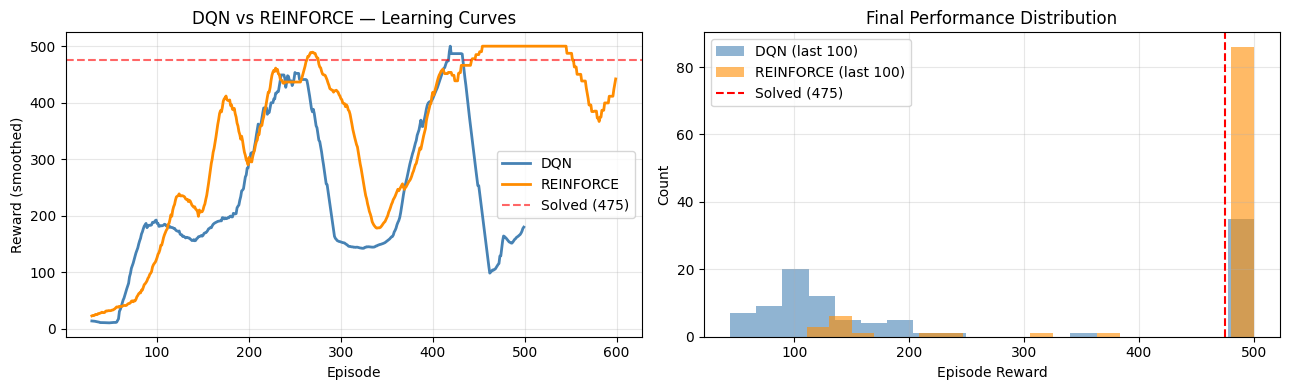


COMPARISON SUMMARY
Method             Avg last 100   Max reward
---------------------------------------------
DQN                       252.5          500
REINFORCE                 454.9          500


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Learning curves ---
ax = axes[0]
w = 30
ax.plot(range(w-1, len(dqn_rewards)), smooth(dqn_rewards, w),
        label='DQN', linewidth=2, color='steelblue')
ax.plot(range(w-1, len(pg_rewards)), smooth(pg_rewards,  w),
        label='REINFORCE', linewidth=2, color='darkorange')
ax.axhline(475, color='red', linestyle='--', alpha=0.6, label='Solved (475)')
ax.set_xlabel('Episode'); ax.set_ylabel('Reward (smoothed)')
ax.set_title('DQN vs REINFORCE — Learning Curves')
ax.legend(); ax.grid(True, alpha=0.3)

# --- Final performance distribution ---
ax = axes[1]
ax.hist(dqn_rewards[-100:], bins=20, alpha=0.6, label='DQN (last 100)', color='steelblue')
ax.hist(pg_rewards[-100:],  bins=20, alpha=0.6, label='REINFORCE (last 100)', color='darkorange')
ax.axvline(475, color='red', linestyle='--', label='Solved (475)')
ax.set_xlabel('Episode Reward'); ax.set_ylabel('Count')
ax.set_title('Final Performance Distribution')
ax.legend(); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_vs_reinforce.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary
print('\n' + '='*60)
print('COMPARISON SUMMARY')
print('='*60)
print(f'{"Method":<15} {"Avg last 100":>15} {"Max reward":>12}')
print('-'*45)
for name, rews in [("DQN", dqn_rewards), ("REINFORCE", pg_rewards)]:
    print(f'{name:<15} {np.mean(rews[-100:]):>15.1f} {max(rews):>12.0f}')

### Exercise 4 — Deep Analysis

**Q1.** Which method converges faster? Explain why in terms of sample efficiency.  
**Q2.** Which method is more stable? Explain the role of variance in REINFORCE.  
**Q3.** DQN is **off-policy** and REINFORCE is **on-policy**. What does this mean? Which one can reuse past experience?  
**Q4.** Implement and test REINFORCE **without** baseline. How does variance change?  
**Q5.** *(Advanced)* If the action space were continuous (e.g. a real-valued torque), which method could still work and which would break? Why?

### Answers :

**A1.** In this experiment, **REINFORCE converges faster** than DQN.  
The learning curve shows REINFORCE reaching rewards close to **500 earlier**, while DQN improves more slowly.  
However, DQN is usually considered more **sample-efficient** because it can reuse past experience through the replay buffer.

**A2.** **DQN is more stable overall.**  
REINFORCE has **high variance** because its updates depend on full episode returns \(G_t\). These returns fluctuate significantly between episodes, causing oscillations in the learning curve. DQN reduces instability using **experience replay and a target network**.

**A3.**  
- **Off-policy (DQN):** the agent can learn from transitions generated by a different policy.  
- **On-policy (REINFORCE):** the agent must learn using data generated by the **current policy** only.  

Therefore, **DQN can reuse past experience** through the replay buffer, while **REINFORCE cannot**.

**A4.** When training **REINFORCE without a baseline**, the variance increases significantly.  
In the experiment, the version **without baseline is much noisier and learns more slowly**, with rewards often staying below 200.  
The baseline (mean return) stabilizes training by **reducing variance in the gradient estimate**.

**A5.**  
If the action space were **continuous**:

- **REINFORCE would still work**, because policy gradient methods can model continuous action distributions (e.g., Gaussian policies).  
- **DQN would fail**, because it requires computing \(max_a Q(s,a)\), which is not feasible when the action space is continuous and infinite.

Training REINFORCE without baseline ...


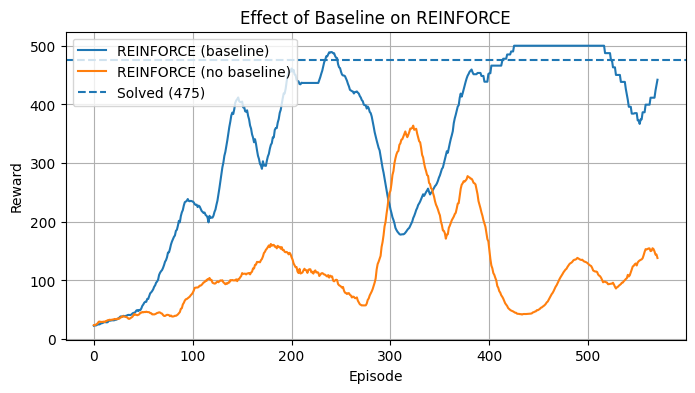

In [13]:
# Exercise 4 Q4 — REINFORCE without baseline

# TODO: Train REINFORCEAgent with use_baseline=False
# and compare learning curve with baseline version.

# YOUR CODE HERE
# Exercise 4 Q4 — REINFORCE without baseline

print("Training REINFORCE without baseline ...")

pg_env = gym.make('CartPole-v1')

pg_agent_nobase = REINFORCEAgent(
    state_dim = pg_env.observation_space.shape[0],
    n_actions = pg_env.action_space.n,
    lr=2e-3,
    gamma=0.99,
    use_baseline=False   # key change
)

pg_rewards_nobase = []
pg_losses_nobase = []

for ep in range(600):

    state, _ = pg_env.reset()
    states, actions, rewards = [], [], []

    while True:
        action = pg_agent_nobase.select_action(state)
        ns, r, term, trunc, _ = pg_env.step(action)

        states.append(state)
        actions.append(action)
        rewards.append(r)

        state = ns

        if term or trunc:
            break

    loss = pg_agent_nobase.update(states, actions, rewards)

    pg_rewards_nobase.append(sum(rewards))
    pg_losses_nobase.append(loss)

pg_env.close()

plt.figure(figsize=(8,4))

plt.plot(smooth(pg_rewards,30), label="REINFORCE (baseline)")
plt.plot(smooth(pg_rewards_nobase,30), label="REINFORCE (no baseline)")

plt.axhline(475, linestyle="--", label="Solved (475)")

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Effect of Baseline on REINFORCE")
plt.legend()
plt.grid(True)

plt.show()



---
## Part 8 — Advanced Extensions (Optional)

###  Challenge 1 — Double DQN

Standard DQN overestimates Q-values because it uses the same network to select **and** evaluate the action.  
**Double DQN** decouples these:
$$\text{target} = r + \gamma Q(s', \underbrace{\arg\max_{a'} Q(s',a';\theta)}_{\text{online net selects}};\underbrace{\theta^-}_{\text{target net evaluates}})$$

Modify `_train_step` to implement Double DQN.

In [16]:
# Challenge 1 — Double DQN target computation
# TODO: Replace the current target computation:
#   next_q = target_net(next_states)
#   target  = r + γ · max(next_q)
# With Double DQN:
#   best_actions = argmax over online_net
#   target       = r + γ · Q(s', best_actions ; θ⁻)

# YOUR CODE HERE

@tf.function
def _train_step(self, states, actions, rewards, next_states, dones):
    """
    One gradient update step using Double DQN.

    Double DQN target:
        a* = argmax_a Q_online(s', a)
        target = r + γ Q_target(s', a*)
    """

    # --- Double DQN target computation ---

    # 1) Use ONLINE network to choose best next action
    next_q_online = self.online_net(next_states, training=False)   # (B, A)
    best_actions  = tf.argmax(next_q_online, axis=1, output_type=tf.int32)

    # 2) Use TARGET network to evaluate that action
    next_q_target = self.target_net(next_states, training=False)   # (B, A)
    idx = tf.stack([tf.range(tf.shape(best_actions)[0]), best_actions], axis=1)
    target_q = tf.gather_nd(next_q_target, idx)                    # (B,)

    # 3) Compute TD targets
    td_targets = rewards + self.gamma * target_q * (1.0 - dones)

    # --- Online network gradient update ---
    with tf.GradientTape() as tape:
        q_all = self.online_net(states, training=True)             # (B, A)

        # Select Q-values for actions actually taken
        action_idx = tf.stack([tf.range(tf.shape(actions)[0]), actions], axis=1)
        q_taken = tf.gather_nd(q_all, action_idx)                  # (B,)

        # Mean squared TD error
        loss = tf.reduce_mean(tf.square(td_targets - q_taken))

    grads = tape.gradient(loss, self.online_net.trainable_variables)
    self.optimiser.apply_gradients(
        zip(grads, self.online_net.trainable_variables)
    )

    return loss

###  Challenge 2 — Actor-Critic (A2C)

Actor-Critic combines the best of both worlds:
- **Actor** $\pi_\theta$: policy network (learns what action to take)
- **Critic** $V_\phi$: value network (reduces variance)

Update rule:
$$\nabla_\theta J = \mathbb{E}\left[\nabla_\theta \log\pi_\theta(a_t|s_t) \cdot \underbrace{(r_t + \gamma V_\phi(s_{t+1}) - V_\phi(s_t))}_{\text{advantage } A_t}\right]$$

**Task:** Implement a minimal A2C agent for CartPole.

In [22]:
# Challenge 2 — Minimal A2C skeleton
class A2CAgent:
    def __init__(self, state_dim, n_actions, lr=1e-3, gamma=0.99):
        # Actor network
        self.actor  = build_policy_net(state_dim, n_actions)
        # Critic network (output = single scalar V(s))
        self.critic = keras.Sequential([
            layers.Input(shape=(state_dim,)),
            layers.Dense(64, activation='relu'),
            layers.Dense(64, activation='relu'),
            layers.Dense(1),   # V(s)
        ])
        self.actor_opt  = keras.optimizers.Adam(lr)
        self.critic_opt = keras.optimizers.Adam(lr)
        self.gamma = gamma

    def update_step(self, state, action, reward, next_state, done):
        """
        One-step A2C update.

        Advantage: A = r + γV(s') - V(s)
        Actor  loss: -log π(a|s) · A
        Critic loss: (A)²
        """
        # TODO: implement the update
        state_t = tf.convert_to_tensor(state[np.newaxis], dtype=tf.float32)
        next_state_t = tf.convert_to_tensor(next_state[np.newaxis], dtype=tf.float32)

        reward_t = tf.constant([[reward]], dtype=tf.float32)
        done_t   = tf.constant([[done]], dtype=tf.float32)

        # -------- Critic forward --------
        V_s  = self.critic(state_t, training=True)
        V_ns = self.critic(next_state_t, training=False)

        target    = reward_t + self.gamma * V_ns * (1.0 - done_t)
        advantage = target - V_s

        # -------- Actor update --------
        with tf.GradientTape() as tape_actor:

            probs = self.actor(state_t, training=True)
            log_probs = tf.math.log(probs + 1e-8)

            log_prob = log_probs[0, action]

            actor_loss = -log_prob * tf.stop_gradient(advantage)

        actor_grads = tape_actor.gradient(actor_loss, self.actor.trainable_variables)
        self.actor_opt.apply_gradients(zip(actor_grads, self.actor.trainable_variables))

        # -------- Critic update --------
        with tf.GradientTape() as tape_critic:

            V_s = self.critic(state_t, training=True)
            critic_loss = tf.square(target - V_s)

        critic_grads = tape_critic.gradient(critic_loss, self.critic.trainable_variables)
        self.critic_opt.apply_gradients(zip(critic_grads, self.critic.trainable_variables))
        pass

print('A2C skeleton created — complete update_step as challenge exercise')

A2C skeleton created — complete update_step as challenge exercise


---
## Summary & Next Week

### What You Did Today

| Component | Key Concept |
|-----------|-------------|
| Replay Buffer | Decorrelates samples, enables mini-batch updates |
| DQN | Q-Learning + neural network + replay + target net |
| REINFORCE | Direct policy optimisation, Monte-Carlo returns |
| Ablation | Each trick matters — replay > target net in practice |

### Key Takeaways

- Tabular Q-Learning **doesn't scale**; neural networks provide function approximation
- DQN's two tricks (replay + target net) solve the **stability problem**
- REINFORCE is conceptually simple but has **high variance**
- Actor-Critic bridges both worlds (next improvement)

###  Next Week — Incremental Learning

RL learns in a **single evolving task**.  
What if tasks change completely, one after another?  
→ **Catastrophic forgetting** is the new enemy.  
→ Solutions: EWC, LwF, Progressive Neural Networks.

---
*End of Lab 3*